In [1]:
from pathlib import Path
import os
import time
import subprocess
import shutil
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
project_root = Path.cwd().parent

benchmark_root = project_root / "data" / "benchmark"
compression_root = project_root / "results" / "images" / "compression"
benchmark_results_root = project_root / "results" / "benchmarks"

compression_root.mkdir(parents=True, exist_ok=True)
benchmark_results_root.mkdir(parents=True, exist_ok=True)

print("Project:", project_root)
print("Compression output:", compression_root)
print("Benchmark output:", benchmark_results_root)

Project: D:\mycode\GlyphForge
Compression output: D:\mycode\GlyphForge\results\images\compression
Benchmark output: D:\mycode\GlyphForge\results\benchmarks


In [3]:
categories = {
    "scanning": "Real5-OmniDocBench-Scanning",
    "warping": "Real5-OmniDocBench-Warping",
    "screen_photography": "Real5-OmniDocBench-Screen-Photography",
    "illumination": "Real5-OmniDocBench-Illumination",
    "skew": "Real5-OmniDocBench-Skew",
}

for category, folder in categories.items():
    folder_path = benchmark_root / folder
    
    files = sorted([
        file
        for file in folder_path.iterdir()
        if file.is_file()
        and file.suffix.lower() in {".png", ".jpg", ".jpeg", ".webp"}
    ])
    
    print(category, len(files))

scanning 5
warping 5
screen_photography 5
illumination 5
skew 5


In [4]:
selected_images = {}

for category, folder in categories.items():
    folder_path = benchmark_root / folder
    
    files = sorted([
        file
        for file in folder_path.iterdir()
        if file.is_file()
        and file.suffix.lower() in {".png", ".jpg", ".jpeg", ".webp"}
    ])
    
    if not files:
        raise FileNotFoundError(folder_path)
    
    selected_images[category] = files[0]

for category, path in selected_images.items():
    print(category, "->", path.name)

scanning -> PPT_1001115_eng_page_003.png
warping -> PPT_1001115_eng_page_003.png
screen_photography -> PPT_1001115_eng_page_003.png
illumination -> PPT_1001115_eng_page_003.png
skew -> PPT_1001115_eng_page_003.png


In [5]:
images = {}

for category, path in selected_images.items():
    image = cv2.imread(str(path))
    
    if image is None:
        raise ValueError(f"Could not load {path}")
    
    images[category] = image
    
    print(
        category,
        image.shape,
        round(path.stat().st_size / 1024, 2),
        "KB"
    )

scanning (1186, 1677, 3) 438.93 KB
warping (2160, 3840, 3) 6656.04 KB
screen_photography (2160, 3840, 3) 10873.0 KB
illumination (2160, 3840, 3) 5778.42 KB
skew (3072, 4096, 3) 13509.62 KB


In [6]:
binary_images = {}

for category, image in images.items():
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    binary_images[category] = binary

In [7]:
binary_images = {}

for category, image in images.items():
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    binary_images[category] = binary

In [8]:
format_directories = {
    "png": compression_root / "png",
    "jpeg": compression_root / "jpeg",
    "webp": compression_root / "webp",
    "avif": compression_root / "avif",
    "jbig2": compression_root / "jbig2",
    "pbm": compression_root / "pbm",
}

for directory in format_directories.values():
    directory.mkdir(parents=True, exist_ok=True)

for name, directory in format_directories.items():
    print(name, "->", directory)

png -> D:\mycode\GlyphForge\results\images\compression\png
jpeg -> D:\mycode\GlyphForge\results\images\compression\jpeg
webp -> D:\mycode\GlyphForge\results\images\compression\webp
avif -> D:\mycode\GlyphForge\results\images\compression\avif
jbig2 -> D:\mycode\GlyphForge\results\images\compression\jbig2
pbm -> D:\mycode\GlyphForge\results\images\compression\pbm


In [10]:
pbm_writer_available = cv2.haveImageWriter(".pbm")

print("PBM writer available:", pbm_writer_available)

PBM writer available: True


In [11]:
wsl_path = shutil.which("wsl.exe")

print("WSL:", wsl_path)

WSL: C:\WINDOWS\system32\wsl.exe


In [12]:
result = subprocess.run(
    [
        "wsl.exe",
        "-d",
        "Ubuntu",
        "--",
        "jbig2",
        "--version"
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print(result.stdout)
print(result.stderr)

Return code: 0

jbig2enc 0.32
 leptonica-1.86.0
  libgif 5.2.2 : libjpeg 8d (libjpeg-turbo 2.1.5) : libpng 1.6.57 : libtiff 4.7.0 : zlib 1.3.1 : libwebp 1.5.0 : libopenjp2 2.5.4



In [13]:
pbm_paths = {}

for category, binary in binary_images.items():
    pbm_path = (
        format_directories["pbm"]
        / f"{category}.pbm"
    )
    
    success = cv2.imwrite(
        str(pbm_path),
        binary
    )
    
    if not success:
        raise RuntimeError(f"Failed to write {pbm_path}")
    
    pbm_paths[category] = pbm_path
    
    print(category, "->", pbm_path)

scanning -> D:\mycode\GlyphForge\results\images\compression\pbm\scanning.pbm
warping -> D:\mycode\GlyphForge\results\images\compression\pbm\warping.pbm
screen_photography -> D:\mycode\GlyphForge\results\images\compression\pbm\screen_photography.pbm
illumination -> D:\mycode\GlyphForge\results\images\compression\pbm\illumination.pbm
skew -> D:\mycode\GlyphForge\results\images\compression\pbm\skew.pbm


In [14]:
for category, path in pbm_paths.items():
    print(
        category,
        "| exists:",
        path.exists(),
        "| size:",
        round(path.stat().st_size / 1024, 2),
        "KB"
    )

scanning | exists: True | size: 243.24 KB
warping | exists: True | size: 1012.51 KB
screen_photography | exists: True | size: 1012.51 KB
illumination | exists: True | size: 1012.51 KB
skew | exists: True | size: 1536.01 KB


In [15]:
for category, path in pbm_paths.items():
    with open(path, "rb") as file:
        header = file.read(2)
    
    print(category, header)

scanning b'P4'
warping b'P4'
screen_photography b'P4'
illumination b'P4'
skew b'P4'


In [16]:
for category, path in pbm_paths.items():
    reconstructed = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )
    
    if reconstructed is None:
        raise RuntimeError(f"Could not read {path}")
    
    print(
        category,
        "| shape:",
        reconstructed.shape,
        "| unique values:",
        np.unique(reconstructed)
    )

scanning | shape: (1186, 1677) | unique values: [  0 255]
warping | shape: (2160, 3840) | unique values: [  0 255]
screen_photography | shape: (2160, 3840) | unique values: [  0 255]
illumination | shape: (2160, 3840) | unique values: [  0 255]
skew | shape: (3072, 4096) | unique values: [  0 255]


In [18]:
wsl_pbm_paths = {}

for category, path in pbm_paths.items():
    windows_path = path.resolve()
    path_string = str(windows_path)

    drive = path_string[0].lower()
    relative_path = path_string[2:].replace("\\", "/")

    linux_path = f"/mnt/{drive}{relative_path}"

    wsl_pbm_paths[category] = linux_path

    print(category, "->", linux_path)

scanning -> /mnt/d/mycode/GlyphForge/results/images/compression/pbm/scanning.pbm
warping -> /mnt/d/mycode/GlyphForge/results/images/compression/pbm/warping.pbm
screen_photography -> /mnt/d/mycode/GlyphForge/results/images/compression/pbm/screen_photography.pbm
illumination -> /mnt/d/mycode/GlyphForge/results/images/compression/pbm/illumination.pbm
skew -> /mnt/d/mycode/GlyphForge/results/images/compression/pbm/skew.pbm


In [19]:
category = "scanning"

result = subprocess.run(
    [
        "wsl.exe",
        "-d",
        "Ubuntu",
        "--",
        "ls",
        "-lh",
        wsl_pbm_paths[category]
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print(result.stdout)
print(result.stderr)

Return code: 0
-rwxrwxrwx 1 root root 244K Aug 24 09:02 /mnt/d/mycode/GlyphForge/results/images/compression/pbm/scanning.pbm




In [21]:
category = "scanning"

result = subprocess.run(
    [
        "wsl.exe",
        "-d",
        "Ubuntu",
        "--",
        "jbig2",
        "-v",
        wsl_pbm_paths[category]
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("Return code:", result.returncode)
print("JBIG2 bytes:", len(result.stdout))
print(result.stderr.decode("utf-8", errors="replace"))

Return code: 0
JBIG2 bytes: 6621
Processing "/mnt/d/mycode/GlyphForge/results/images/compression/pbm/scanning.pbm"...
source image: 1677 x 1186 (1 bits) 0dpi x 0dpi, refcount = 1
thresholded image: 1677 x 1186 (1 bits) 0dpi x 0dpi, refcount = 2



In [22]:
jbig2_paths = {}

for category, pbm_path in pbm_paths.items():
    output_path = (
        format_directories["jbig2"]
        / f"{category}.jb2"
    )
    
    result = subprocess.run(
        [
            "wsl.exe",
            "-d",
            "Ubuntu",
            "--",
            "jbig2",
            wsl_pbm_paths[category]
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )
    
    if result.returncode != 0:
        raise RuntimeError(
            result.stderr.decode("utf-8", errors="replace")
        )
    
    output_path.write_bytes(result.stdout)
    
    jbig2_paths[category] = output_path
    
    print(
        category,
        "|",
        round(output_path.stat().st_size / 1024, 2),
        "KB"
    )

scanning | 6.47 KB
warping | 32.75 KB
screen_photography | 11.81 KB
illumination | 6.71 KB
skew | 134.56 KB


In [23]:
for category, path in jbig2_paths.items():
    print(
        category,
        "| exists:",
        path.exists(),
        "| size:",
        round(path.stat().st_size / 1024, 2),
        "KB"
    )

scanning | exists: True | size: 6.47 KB
warping | exists: True | size: 32.75 KB
screen_photography | exists: True | size: 11.81 KB
illumination | exists: True | size: 6.71 KB
skew | exists: True | size: 134.56 KB


In [24]:
jbig2_symbol_root = compression_root / "jbig2_symbol"

jbig2_symbol_root.mkdir(
    parents=True,
    exist_ok=True
)

print(jbig2_symbol_root)

D:\mycode\GlyphForge\results\images\compression\jbig2_symbol


In [26]:
jbig2_symbol_paths = {}

for category, pbm_path in pbm_paths.items():
    output_path = (
        jbig2_symbol_root
        / f"{category}.jb2"
    )

    result = subprocess.run(
        [
            "wsl.exe",
            "-d",
            "Ubuntu",
            "--",
            "jbig2",
            "-s",
            "-v",
            wsl_pbm_paths[category]
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    if result.returncode != 0:
        raise RuntimeError(
            result.stderr.decode(
                "utf-8",
                errors="replace"
            )
        )

    output_path.write_bytes(result.stdout)

    jbig2_symbol_paths[category] = output_path

    print(
        category,
        "|",
        round(
            output_path.stat().st_size / 1024,
            2
        ),
        "KB"
    )

scanning | 5.89 KB
warping | 33.58 KB
screen_photography | 10.18 KB
illumination | 6.96 KB
skew | 139.67 KB


In [27]:
for category, path in jbig2_symbol_paths.items():
    print(
        category,
        "| exists:",
        path.exists(),
        "| size:",
        round(path.stat().st_size / 1024, 2),
        "KB"
    )

scanning | exists: True | size: 5.89 KB
warping | exists: True | size: 33.58 KB
screen_photography | exists: True | size: 10.18 KB
illumination | exists: True | size: 6.96 KB
skew | exists: True | size: 139.67 KB


In [28]:
jbig2_comparison = []

for category in categories:
    generic_size = jbig2_paths[category].stat().st_size
    symbol_size = jbig2_symbol_paths[category].stat().st_size

    jbig2_comparison.append({
        "category": category,
        "generic_kb": generic_size / 1024,
        "symbol_kb": symbol_size / 1024,
        "symbol_vs_generic_percent": (
            symbol_size / generic_size * 100
        )
    })

jbig2_comparison = pd.DataFrame(
    jbig2_comparison
)

jbig2_comparison

,category,generic_kb,symbol_kb,symbol_vs_generic_percent
0,scanning,6.465820,5.887695,91.058752
1,warping,32.750977,33.583984,102.543459
2,screen_photography,11.805664,10.179688,86.227149
3,illumination,6.708984,6.957031,103.697234
4,skew,134.555664,139.674805,103.804478


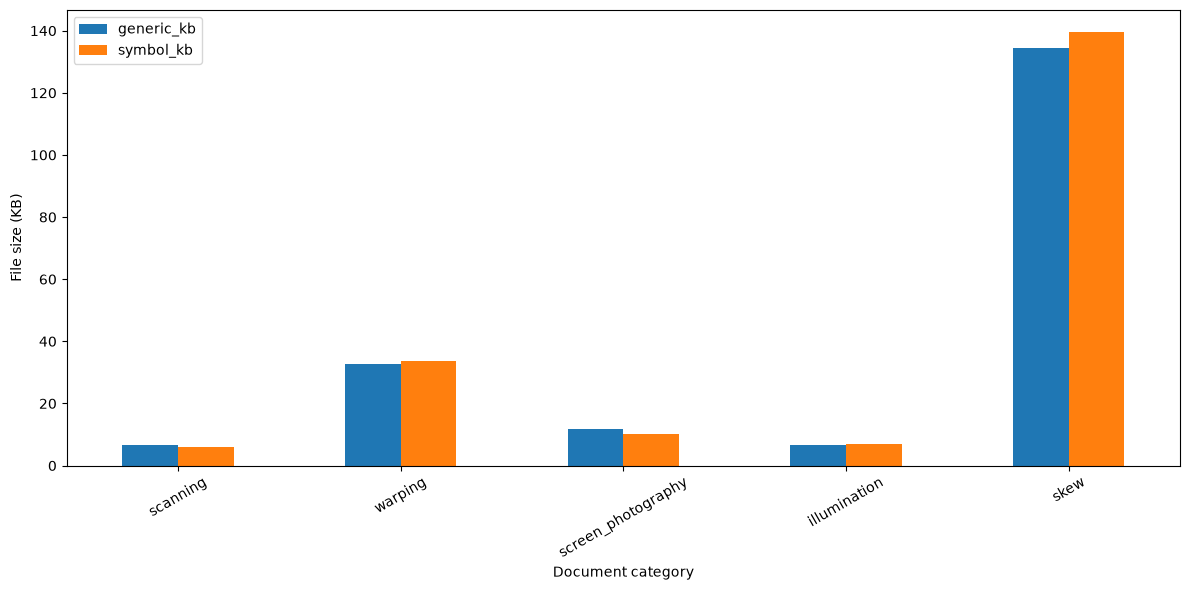

In [29]:
plot_data = jbig2_comparison.set_index("category")[
    ["generic_kb", "symbol_kb"]
]

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("File size (KB)")
plt.xlabel("Document category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [30]:
jbig2_decoded_root = compression_root / "jbig2_decoded"

jbig2_decoded_root.mkdir(
    parents=True,
    exist_ok=True
)

jbig2_decoded_paths = {}

for category, jb2_path in jbig2_paths.items():
    output_path = (
        jbig2_decoded_root
        / f"{category}.pbm"
    )

    windows_path = jb2_path.resolve()

    drive = windows_path.drive[0].lower()
    relative_path = (
        windows_path.as_posix()
        .split(":/", 1)[1]
    )

    linux_input = (
        f"/mnt/{drive}/"
        f"{relative_path}"
    )

    windows_output = output_path.resolve()

    drive = windows_output.drive[0].lower()
    relative_path = (
        windows_output.as_posix()
        .split(":/", 1)[1]
    )

    linux_output = (
        f"/mnt/{drive}/"
        f"{relative_path}"
    )

    result = subprocess.run(
        [
            "wsl.exe",
            "-d",
            "Ubuntu",
            "--",
            "jbig2dec",
            "-q",
            "-t",
            "pbm",
            "-o",
            linux_output,
            linux_input
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    if result.returncode != 0:
        raise RuntimeError(
            result.stderr.decode(
                "utf-8",
                errors="replace"
            )
        )

    jbig2_decoded_paths[category] = output_path

    print(
        category,
        "|",
        output_path.exists(),
        "|",
        round(
            output_path.stat().st_size / 1024,
            2
        ),
        "KB"
    )

scanning | True | 243.24 KB
warping | True | 1012.51 KB
screen_photography | True | 1012.51 KB
illumination | True | 1012.51 KB
skew | True | 1536.01 KB


In [31]:
for category, path in jbig2_decoded_paths.items():
    image = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise RuntimeError(
            f"Could not read {path}"
        )

    print(
        category,
        "| shape:",
        image.shape,
        "| values:",
        np.unique(image)
    )

scanning | shape: (1186, 1677) | values: [  0 255]
warping | shape: (2160, 3840) | values: [  0 255]
screen_photography | shape: (2160, 3840) | values: [  0 255]
illumination | shape: (2160, 3840) | values: [  0 255]
skew | shape: (3072, 4096) | values: [  0 255]


In [33]:
roundtrip_results = []

for category in categories:
    original = binary_images[category]

    decoded = cv2.imread(
        str(jbig2_decoded_paths[category]),
        cv2.IMREAD_GRAYSCALE
    )

    if original.shape != decoded.shape:
        roundtrip_results.append({
            "category": category,
            "same_shape": False,
            "changed_pixels": None,
            "changed_pixel_percent": None,
            "exact_match": False
        })
        continue

    difference = cv2.compare(
        original,
        decoded,
        cv2.CMP_NE
    )

    changed_pixels = int(
        np.count_nonzero(difference)
    )

    total_pixels = original.size

    changed_pixel_percent = (
        changed_pixels / total_pixels * 100
    )

    roundtrip_results.append({
        "category": category,
        "same_shape": True,
        "changed_pixels": changed_pixels,
        "changed_pixel_percent": changed_pixel_percent,
        "exact_match": changed_pixels == 0
    })

roundtrip_results = pd.DataFrame(
    roundtrip_results
)

roundtrip_results

,category,same_shape,changed_pixels,changed_pixel_percent,exact_match
0,scanning,True,0,0.0,True
1,warping,True,0,0.0,True
2,screen_photography,True,0,0.0,True
3,illumination,True,0,0.0,True
4,skew,True,0,0.0,True


In [34]:
jbig2_symbol_decoded_root = (
    compression_root / "jbig2_symbol_decoded"
)

jbig2_symbol_decoded_root.mkdir(
    parents=True,
    exist_ok=True
)

jbig2_symbol_decoded_paths = {}

for category, jb2_path in jbig2_symbol_paths.items():
    output_path = (
        jbig2_symbol_decoded_root
        / f"{category}.pbm"
    )

    windows_input = jb2_path.resolve()
    windows_output = output_path.resolve()

    drive = windows_input.drive[0].lower()
    relative_input = (
        windows_input.as_posix()
        .split(":/", 1)[1]
    )

    linux_input = (
        f"/mnt/{drive}/{relative_input}"
    )

    drive = windows_output.drive[0].lower()
    relative_output = (
        windows_output.as_posix()
        .split(":/", 1)[1]
    )

    linux_output = (
        f"/mnt/{drive}/{relative_output}"
    )

    result = subprocess.run(
        [
            "wsl.exe",
            "-d",
            "Ubuntu",
            "--",
            "jbig2dec",
            "-q",
            "-t",
            "pbm",
            "-o",
            linux_output,
            linux_input
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    if result.returncode != 0:
        raise RuntimeError(
            result.stderr.decode(
                "utf-8",
                errors="replace"
            )
        )

    jbig2_symbol_decoded_paths[category] = output_path

    print(
        category,
        "|",
        output_path.exists(),
        "|",
        round(
            output_path.stat().st_size / 1024,
            2
        ),
        "KB"
    )

scanning | True | 243.24 KB
warping | True | 1012.51 KB
screen_photography | True | 1012.51 KB
illumination | True | 1012.51 KB
skew | True | 1536.01 KB


In [35]:
symbol_roundtrip_results = []

for category in categories:
    original = binary_images[category]

    decoded = cv2.imread(
        str(jbig2_symbol_decoded_paths[category]),
        cv2.IMREAD_GRAYSCALE
    )

    if original.shape != decoded.shape:
        symbol_roundtrip_results.append({
            "category": category,
            "same_shape": False,
            "changed_pixels": None,
            "changed_pixel_percent": None,
            "exact_match": False
        })
        continue

    difference = cv2.compare(
        original,
        decoded,
        cv2.CMP_NE
    )

    changed_pixels = int(
        np.count_nonzero(difference)
    )

    total_pixels = original.size

    changed_pixel_percent = (
        changed_pixels / total_pixels * 100
    )

    symbol_roundtrip_results.append({
        "category": category,
        "same_shape": True,
        "changed_pixels": changed_pixels,
        "changed_pixel_percent": changed_pixel_percent,
        "exact_match": changed_pixels == 0
    })

symbol_roundtrip_results = pd.DataFrame(
    symbol_roundtrip_results
)

symbol_roundtrip_results

,category,same_shape,changed_pixels,changed_pixel_percent,exact_match
0,scanning,True,682,0.034290,False
1,warping,True,461,0.005558,False
2,screen_photography,True,2082,0.025101,False
3,illumination,True,0,0.000000,True
4,skew,True,592,0.004705,False


In [36]:
jbig2_refined_root = compression_root / "jbig2_symbol_refined"

jbig2_refined_root.mkdir(
    parents=True,
    exist_ok=True
)

print(jbig2_refined_root)

D:\mycode\GlyphForge\results\images\compression\jbig2_symbol_refined


In [37]:
jbig2_refined_paths = {}

for category, pbm_path in pbm_paths.items():
    output_path = (
        jbig2_refined_root
        / f"{category}.jb2"
    )

    result = subprocess.run(
        [
            "wsl.exe",
            "-d",
            "Ubuntu",
            "--",
            "jbig2",
            "-s",
            "-r",
            "-v",
            wsl_pbm_paths[category]
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    if result.returncode != 0:
        raise RuntimeError(
            result.stderr.decode(
                "utf-8",
                errors="replace"
            )
        )

    output_path.write_bytes(result.stdout)

    jbig2_refined_paths[category] = output_path

    print(
        category,
        "|",
        round(
            output_path.stat().st_size / 1024,
            2
        ),
        "KB"
    )

RuntimeError: Refinement broke in recent releases since it's rarely used. If you need it you should bug agl@imperialviolet.org to fix it


In [38]:
generic_roundtrip_results = []

for category in categories:
    original = binary_images[category]

    decoded = cv2.imread(
        str(jbig2_decoded_paths[category]),
        cv2.IMREAD_GRAYSCALE
    )

    if original.shape != decoded.shape:
        generic_roundtrip_results.append({
            "category": category,
            "same_shape": False,
            "changed_pixels": None,
            "changed_pixel_percent": None,
            "exact_match": False
        })
        continue

    difference = cv2.compare(
        original,
        decoded,
        cv2.CMP_NE
    )

    changed_pixels = int(
        np.count_nonzero(difference)
    )

    total_pixels = original.size

    generic_roundtrip_results.append({
        "category": category,
        "same_shape": True,
        "changed_pixels": changed_pixels,
        "changed_pixel_percent": (
            changed_pixels / total_pixels * 100
        ),
        "exact_match": changed_pixels == 0
    })

generic_roundtrip_results = pd.DataFrame(
    generic_roundtrip_results
)

generic_roundtrip_results

,category,same_shape,changed_pixels,changed_pixel_percent,exact_match
0,scanning,True,0,0.0,True
1,warping,True,0,0.0,True
2,screen_photography,True,0,0.0,True
3,illumination,True,0,0.0,True
4,skew,True,0,0.0,True


In [40]:
jbig2_integrity_comparison = generic_roundtrip_results.merge(
    symbol_roundtrip_results,
    on="category",
    suffixes=("_generic", "_symbol")
)

jbig2_integrity_comparison

,category,same_shape_generic,changed_pixels_generic,changed_pixel_percent_generic,exact_match_generic,same_shape_symbol,changed_pixels_symbol,changed_pixel_percent_symbol,exact_match_symbol
0,scanning,True,0,0.0,True,True,682,0.034290,False
1,warping,True,0,0.0,True,True,461,0.005558,False
2,screen_photography,True,0,0.0,True,True,2082,0.025101,False
3,illumination,True,0,0.0,True,True,0,0.000000,True
4,skew,True,0,0.0,True,True,592,0.004705,False


In [41]:
compression_comparison = jbig2_comparison.copy()

compression_comparison

,category,generic_kb,symbol_kb,symbol_vs_generic_percent
0,scanning,6.465820,5.887695,91.058752
1,warping,32.750977,33.583984,102.543459
2,screen_photography,11.805664,10.179688,86.227149
3,illumination,6.708984,6.957031,103.697234
4,skew,134.555664,139.674805,103.804478


In [42]:
generic_roundtrip_results = []

for category in categories:
    original = binary_images[category]

    decoded = cv2.imread(
        str(jbig2_decoded_paths[category]),
        cv2.IMREAD_GRAYSCALE
    )

    if original.shape != decoded.shape:
        generic_roundtrip_results.append({
            "category": category,
            "same_shape": False,
            "changed_pixels": None,
            "changed_pixel_percent": None,
            "exact_match": False
        })
        continue

    difference = cv2.compare(
        original,
        decoded,
        cv2.CMP_NE
    )

    changed_pixels = int(
        np.count_nonzero(difference)
    )

    total_pixels = original.size

    generic_roundtrip_results.append({
        "category": category,
        "same_shape": True,
        "changed_pixels": changed_pixels,
        "changed_pixel_percent": (
            changed_pixels / total_pixels * 100
        ),
        "exact_match": changed_pixels == 0
    })

generic_roundtrip_results = pd.DataFrame(
    generic_roundtrip_results
)

generic_roundtrip_results

,category,same_shape,changed_pixels,changed_pixel_percent,exact_match
0,scanning,True,0,0.0,True
1,warping,True,0,0.0,True
2,screen_photography,True,0,0.0,True
3,illumination,True,0,0.0,True
4,skew,True,0,0.0,True


In [46]:
avif_available = cv2.haveImageWriter(".avif")

print("AVIF encoder available:", avif_available)

AVIF encoder available: False


In [48]:
for category, binary in binary_images.items():
    png_path = format_directories["png"] / f"{category}.png"
    jpeg_path = format_directories["jpeg"] / f"{category}.jpg"
    webp_path = format_directories["webp"] / f"{category}.webp"

    png_success = cv2.imwrite(
        str(png_path),
        binary,
        [cv2.IMWRITE_PNG_COMPRESSION, 9]
    )

    jpeg_success = cv2.imwrite(
        str(jpeg_path),
        binary,
        [cv2.IMWRITE_JPEG_QUALITY, 90]
    )

    webp_success = cv2.imwrite(
        str(webp_path),
        binary,
        [cv2.IMWRITE_WEBP_QUALITY, 90]
    )

    if not png_success:
        raise RuntimeError(f"Failed to create {png_path}")

    if not jpeg_success:
        raise RuntimeError(f"Failed to create {jpeg_path}")

    if not webp_success:
        raise RuntimeError(f"Failed to create {webp_path}")

    if avif_available:
        avif_path = format_directories["avif"] / f"{category}.avif"

        avif_success = cv2.imwrite(
            str(avif_path),
            binary
        )

        if not avif_success:
            raise RuntimeError(f"Failed to create {avif_path}")

    print(category, "done")

scanning done
warping done
screen_photography done
illumination done
skew done


In [49]:
for name, directory in format_directories.items():
    print(f"\n{name.upper()}")

    if directory.exists():
        for path in sorted(directory.iterdir()):
            if path.is_file():
                print(
                    " ",
                    path.name,
                    "|",
                    round(path.stat().st_size / 1024, 2),
                    "KB"
                )
    else:
        print("  directory does not exist")


PNG
  illumination.png | 29.24 KB
  scanning.png | 23.12 KB
  screen_photography.png | 46.59 KB
  skew.png | 298.72 KB
  warping.png | 102.31 KB

JPEG
  illumination.jpg | 236.88 KB
  scanning.jpg | 202.85 KB
  screen_photography.jpg | 451.82 KB
  skew.jpg | 2054.23 KB
  warping.jpg | 750.96 KB

WEBP
  illumination.webp | 70.0 KB
  scanning.webp | 73.73 KB
  screen_photography.webp | 133.8 KB
  skew.webp | 1014.95 KB
  warping.webp | 293.26 KB

AVIF

JBIG2
  illumination.jb2 | 6.71 KB
  scanning.jb2 | 6.47 KB
  scanning_decoded.pbm | 243.24 KB
  screen_photography.jb2 | 11.81 KB
  skew.jb2 | 134.56 KB
  warping.jb2 | 32.75 KB

PBM
  illumination.pbm | 1012.51 KB
  scanning.pbm | 243.24 KB
  screen_photography.pbm | 1012.51 KB
  skew.pbm | 1536.01 KB
  warping.pbm | 1012.51 KB


In [50]:
codec_benchmark = []

for category in categories:
    source_size = (
        pbm_paths[category]
        .stat()
        .st_size
    )

    record = {
        "category": category,
        "binary_source_size_bytes": source_size,
        "png_size_bytes": (
            format_directories["png"]
            / f"{category}.png"
        ).stat().st_size,
        "jpeg_size_bytes": (
            format_directories["jpeg"]
            / f"{category}.jpg"
        ).stat().st_size,
        "webp_size_bytes": (
            format_directories["webp"]
            / f"{category}.webp"
        ).stat().st_size,
        "jbig2_generic_size_bytes": (
            jbig2_paths[category]
        ).stat().st_size,
        "jbig2_symbol_size_bytes": (
            jbig2_symbol_paths[category]
        ).stat().st_size
    }

    codec_benchmark.append(record)

codec_benchmark = pd.DataFrame(
    codec_benchmark
)

codec_benchmark

,category,binary_source_size_bytes,png_size_bytes,jpeg_size_bytes,webp_size_bytes,jbig2_generic_size_bytes,jbig2_symbol_size_bytes
0,scanning,249073,23677,207723,75502,6621,6029
1,warping,1036813,104762,768981,300296,33537,34390
2,screen_photography,1036813,47711,462666,137010,12089,10424
3,illumination,1036813,29942,242561,71680,6870,7124
4,skew,1572877,305888,2103531,1039308,137785,143027


In [51]:
codec_size_columns = [
    column
    for column in codec_benchmark.columns
    if column.endswith("_bytes")
]

for column in codec_size_columns:
    codec_benchmark[
        column.replace("_bytes", "_kb")
    ] = (
        codec_benchmark[column] / 1024
    )

codec_benchmark

,category,binary_source_size_bytes,png_size_bytes,jpeg_size_bytes,webp_size_bytes,jbig2_generic_size_bytes,jbig2_symbol_size_bytes,binary_source_size_kb,png_size_kb,jpeg_size_kb,webp_size_kb,jbig2_generic_size_kb,jbig2_symbol_size_kb
0,scanning,249073,23677,207723,75502,6621,6029,243.235352,23.122070,202.854492,73.732422,6.465820,5.887695
1,warping,1036813,104762,768981,300296,33537,34390,1012.512695,102.306641,750.958008,293.257812,32.750977,33.583984
2,screen_photography,1036813,47711,462666,137010,12089,10424,1012.512695,46.592773,451.822266,133.798828,11.805664,10.179688
3,illumination,1036813,29942,242561,71680,6870,7124,1012.512695,29.240234,236.875977,70.000000,6.708984,6.957031
4,skew,1572877,305888,2103531,1039308,137785,143027,1536.012695,298.718750,2054.229492,1014.949219,134.555664,139.674805


In [52]:
codec_methods = {
    "png": "png_size_bytes",
    "jpeg": "jpeg_size_bytes",
    "webp": "webp_size_bytes",
    "jbig2_generic": "jbig2_generic_size_bytes",
    "jbig2_symbol": "jbig2_symbol_size_bytes"
}

for method, column in codec_methods.items():
    codec_benchmark[
        f"{method}_ratio"
    ] = (
        codec_benchmark["binary_source_size_bytes"]
        / codec_benchmark[column]
    )

codec_benchmark

,category,binary_source_size_bytes,png_size_bytes,jpeg_size_bytes,webp_size_bytes,jbig2_generic_size_bytes,jbig2_symbol_size_bytes,binary_source_size_kb,png_size_kb,jpeg_size_kb,webp_size_kb,jbig2_generic_size_kb,jbig2_symbol_size_kb,png_ratio,jpeg_ratio,webp_ratio,jbig2_generic_ratio,jbig2_symbol_ratio
0,scanning,249073,23677,207723,75502,6621,6029,243.235352,23.122070,202.854492,73.732422,6.465820,5.887695,10.519618,1.199063,3.298893,37.618638,41.312490
1,warping,1036813,104762,768981,300296,33537,34390,1012.512695,102.306641,750.958008,293.257812,32.750977,33.583984,9.896842,1.348295,3.452637,30.915496,30.148677
2,screen_photography,1036813,47711,462666,137010,12089,10424,1012.512695,46.592773,451.822266,133.798828,11.805664,10.179688,21.731110,2.240954,7.567426,85.764993,99.464025
3,illumination,1036813,29942,242561,71680,6870,7124,1012.512695,29.240234,236.875977,70.000000,6.708984,6.957031,34.627380,4.274442,14.464467,150.918923,145.538040
4,skew,1572877,305888,2103531,1039308,137785,143027,1536.012695,298.718750,2054.229492,1014.949219,134.555664,139.674805,5.142003,0.747732,1.513389,11.415444,10.997063


In [53]:
for method, column in codec_methods.items():
    codec_benchmark[
        f"{method}_reduction_percent"
    ] = (
        1
        - codec_benchmark[column]
        / codec_benchmark["binary_source_size_bytes"]
    ) * 100

codec_benchmark

,category,binary_source_size_bytes,png_size_bytes,jpeg_size_bytes,webp_size_bytes,jbig2_generic_size_bytes,jbig2_symbol_size_bytes,binary_source_size_kb,png_size_kb,jpeg_size_kb,...,png_ratio,jpeg_ratio,webp_ratio,jbig2_generic_ratio,jbig2_symbol_ratio,png_reduction_percent,jpeg_reduction_percent,webp_reduction_percent,jbig2_generic_reduction_percent,jbig2_symbol_reduction_percent
0,scanning,249073,23677,207723,75502,6621,6029,243.235352,23.122070,202.854492,...,10.519618,1.199063,3.298893,37.618638,41.312490,90.493952,16.601559,69.686799,97.341743,97.579425
1,warping,1036813,104762,768981,300296,33537,34390,1012.512695,102.306641,750.958008,...,9.896842,1.348295,3.452637,30.915496,30.148677,89.895767,25.832238,71.036629,96.765376,96.683105
2,screen_photography,1036813,47711,462666,137010,12089,10424,1012.512695,46.592773,451.822266,...,21.731110,2.240954,7.567426,85.764993,99.464025,95.398302,55.376138,86.785467,98.834023,98.994611
3,illumination,1036813,29942,242561,71680,6870,7124,1012.512695,29.240234,236.875977,...,34.627380,4.274442,14.464467,150.918923,145.538040,97.112112,76.605135,93.086506,99.337393,99.312894
4,skew,1572877,305888,2103531,1039308,137785,143027,1536.012695,298.718750,2054.229492,...,5.142003,0.747732,1.513389,11.415444,10.997063,80.552325,-33.737794,33.923123,91.239938,90.906663


In [54]:
codec_display = codec_benchmark[
    [
        "category",
        "binary_source_size_kb",
        "png_size_kb",
        "jpeg_size_kb",
        "webp_size_kb",
        "jbig2_generic_size_kb",
        "jbig2_symbol_size_kb",
        "png_ratio",
        "webp_ratio",
        "jbig2_generic_ratio",
        "jbig2_symbol_ratio"
    ]
]

codec_display

,category,binary_source_size_kb,png_size_kb,jpeg_size_kb,webp_size_kb,jbig2_generic_size_kb,jbig2_symbol_size_kb,png_ratio,webp_ratio,jbig2_generic_ratio,jbig2_symbol_ratio
0,scanning,243.235352,23.122070,202.854492,73.732422,6.465820,5.887695,10.519618,3.298893,37.618638,41.312490
1,warping,1012.512695,102.306641,750.958008,293.257812,32.750977,33.583984,9.896842,3.452637,30.915496,30.148677
2,screen_photography,1012.512695,46.592773,451.822266,133.798828,11.805664,10.179688,21.731110,7.567426,85.764993,99.464025
3,illumination,1012.512695,29.240234,236.875977,70.000000,6.708984,6.957031,34.627380,14.464467,150.918923,145.538040
4,skew,1536.012695,298.718750,2054.229492,1014.949219,134.555664,139.674805,5.142003,1.513389,11.415444,10.997063


In [55]:
codec_benchmark = codec_benchmark.merge(
    generic_roundtrip_results[
        [
            "category",
            "exact_match",
            "changed_pixels",
            "changed_pixel_percent"
        ]
    ],
    on="category"
)

codec_benchmark = codec_benchmark.rename(
    columns={
        "exact_match": "jbig2_generic_exact",
        "changed_pixels": "jbig2_generic_changed_pixels",
        "changed_pixel_percent": "jbig2_generic_changed_pixel_percent"
    }
)

codec_benchmark = codec_benchmark.merge(
    symbol_roundtrip_results[
        [
            "category",
            "exact_match",
            "changed_pixels",
            "changed_pixel_percent"
        ]
    ],
    on="category"
)

codec_benchmark = codec_benchmark.rename(
    columns={
        "exact_match": "jbig2_symbol_exact",
        "changed_pixels": "jbig2_symbol_changed_pixels",
        "changed_pixel_percent": "jbig2_symbol_changed_pixel_percent"
    }
)

codec_benchmark

,category,binary_source_size_bytes,png_size_bytes,jpeg_size_bytes,webp_size_bytes,jbig2_generic_size_bytes,jbig2_symbol_size_bytes,binary_source_size_kb,png_size_kb,jpeg_size_kb,...,jpeg_reduction_percent,webp_reduction_percent,jbig2_generic_reduction_percent,jbig2_symbol_reduction_percent,jbig2_generic_exact,jbig2_generic_changed_pixels,jbig2_generic_changed_pixel_percent,jbig2_symbol_exact,jbig2_symbol_changed_pixels,jbig2_symbol_changed_pixel_percent
0,scanning,249073,23677,207723,75502,6621,6029,243.235352,23.122070,202.854492,...,16.601559,69.686799,97.341743,97.579425,True,0,0.0,False,682,0.034290
1,warping,1036813,104762,768981,300296,33537,34390,1012.512695,102.306641,750.958008,...,25.832238,71.036629,96.765376,96.683105,True,0,0.0,False,461,0.005558
2,screen_photography,1036813,47711,462666,137010,12089,10424,1012.512695,46.592773,451.822266,...,55.376138,86.785467,98.834023,98.994611,True,0,0.0,False,2082,0.025101
3,illumination,1036813,29942,242561,71680,6870,7124,1012.512695,29.240234,236.875977,...,76.605135,93.086506,99.337393,99.312894,True,0,0.0,True,0,0.000000
4,skew,1572877,305888,2103531,1039308,137785,143027,1536.012695,298.718750,2054.229492,...,-33.737794,33.923123,91.239938,90.906663,True,0,0.0,False,592,0.004705


In [56]:
jbig2_final = codec_benchmark[
    [
        "category",
        "binary_source_size_kb",
        "jbig2_generic_size_kb",
        "jbig2_generic_ratio",
        "jbig2_generic_reduction_percent",
        "jbig2_generic_exact",
        "jbig2_symbol_size_kb",
        "jbig2_symbol_ratio",
        "jbig2_symbol_reduction_percent",
        "jbig2_symbol_exact",
        "jbig2_symbol_changed_pixel_percent"
    ]
]

jbig2_final

,category,binary_source_size_kb,jbig2_generic_size_kb,jbig2_generic_ratio,jbig2_generic_reduction_percent,jbig2_generic_exact,jbig2_symbol_size_kb,jbig2_symbol_ratio,jbig2_symbol_reduction_percent,jbig2_symbol_exact,jbig2_symbol_changed_pixel_percent
0,scanning,243.235352,6.465820,37.618638,97.341743,True,5.887695,41.312490,97.579425,False,0.034290
1,warping,1012.512695,32.750977,30.915496,96.765376,True,33.583984,30.148677,96.683105,False,0.005558
2,screen_photography,1012.512695,11.805664,85.764993,98.834023,True,10.179688,99.464025,98.994611,False,0.025101
3,illumination,1012.512695,6.708984,150.918923,99.337393,True,6.957031,145.538040,99.312894,True,0.000000
4,skew,1536.012695,134.555664,11.415444,91.239938,True,139.674805,10.997063,90.906663,False,0.004705


In [57]:
codec_benchmark_path = (
    benchmark_results_root
    / "codec_comparison.csv"
)

codec_benchmark.to_csv(
    codec_benchmark_path,
    index=False
)

print(codec_benchmark_path)

D:\mycode\GlyphForge\results\benchmarks\codec_comparison.csv
